In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit

import sys
sys.path.append("../src")
from energy_forecasting import EnergyForecaster

In [30]:
df = pd.read_csv(
    "transformed_YWNC2cone.csv",
    index_col=0,        # first column is the index
    parse_dates=True   # parse it as datetime
)

In [31]:
df.dropna(inplace = True)

In [32]:
df.columns

Index(['HOURLY_KWH', 'AVG_CURRENT', 'AVG_V_LN', 'power_proxy', 'hour',
       'weekday', 'day_of_month', 'month', 'week_of_year', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
       'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_24', 'kwh_lag_168',
       'kwh_roll_3h_mean', 'kwh_roll_24h_mean', 'kwh_roll_24h_std',
       'kwh_roll_24h_min', 'kwh_roll_24h_max', 'kwh_roll_168h_mean',
       'kwh_roll_168h_std', 'kwh_ratio_to_24h_avg', 'kwh_ratio_to_168h_avg',
       'HOURLY_KWH_capped'],
      dtype='object')

In [33]:

rf_feature_cols = ['AVG_CURRENT', 'AVG_V_LN', 'power_proxy', 'hour',
       'weekday', 'day_of_month', 'month', 'week_of_year', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
       'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_24', 'kwh_lag_168',
       'kwh_roll_3h_mean', 'kwh_roll_24h_mean', 'kwh_roll_24h_std',
       'kwh_roll_24h_min', 'kwh_roll_24h_max', 'kwh_roll_168h_mean',
       'kwh_roll_168h_std', 'kwh_ratio_to_24h_avg', 'kwh_ratio_to_168h_avg']

rf_X = df[rf_feature_cols]


y = df['HOURLY_KWH_capped']
target_col = 'HOURLY_KWH_capped'

In [34]:
# Train Test Spitt
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train[rf_feature_cols]
X_test = test[rf_feature_cols]
y_train = train[target_col]
y_test = test[target_col]

In [35]:
rf_best = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [36]:
rf_best.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [37]:
df.isnull().sum()

HOURLY_KWH               0
AVG_CURRENT              0
AVG_V_LN                 0
power_proxy              0
hour                     0
weekday                  0
day_of_month             0
month                    0
week_of_year             0
hour_sin                 0
hour_cos                 0
weekday_sin              0
weekday_cos              0
month_sin                0
month_cos                0
kwh_lag_1                0
kwh_lag_2                0
kwh_lag_24               0
kwh_lag_168              0
kwh_roll_3h_mean         0
kwh_roll_24h_mean        0
kwh_roll_24h_std         0
kwh_roll_24h_min         0
kwh_roll_24h_max         0
kwh_roll_168h_mean       0
kwh_roll_168h_std        0
kwh_ratio_to_24h_avg     0
kwh_ratio_to_168h_avg    0
HOURLY_KWH_capped        0
dtype: int64

In [38]:
# y_pred on test and train
y_test_pred = rf_best.predict(X_test)
y_train_pred = rf_best.predict(X_train)

# Evaluate R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

# RMSE
rmse = root_mean_squared_error(y_test, y_test_pred)
print(f"RMSE: {rmse:.4f}")

# MAE
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Mean Absolute Error: {mae:.4f}")

# Cross-Validation (R²)
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=24*7,
    gap=24
)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {fold+1}: train={len(train_idx)}, test={len(test_idx)}")
    
cv_r2 = cross_val_score(
    rf_best,
    X_train,
    y_train,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

print("CV R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())

Train R²: 0.9974358604231309
Test R² : 0.9907496135704527
RMSE: 0.0462
Mean Absolute Error: 0.0313
Fold 1: train=1783, test=168
Fold 2: train=1951, test=168
Fold 3: train=2119, test=168
Fold 4: train=2287, test=168
Fold 5: train=2455, test=168
CV R² scores: [0.97797161 0.99239494 0.98410768 0.98726775 0.98754663]
Mean CV R²: 0.985857721813048


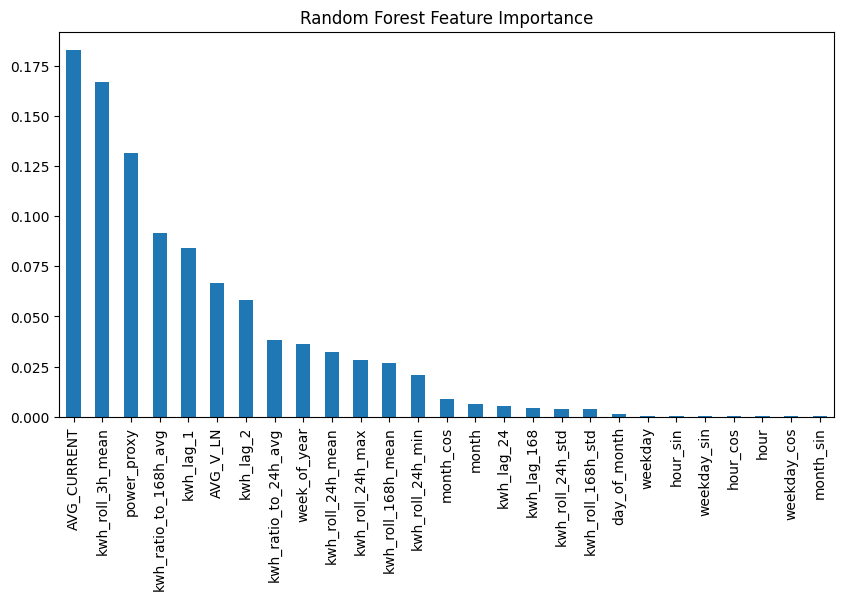

In [39]:
plt.figure(figsize=(7, 3))
feat_imp = pd.Series(rf_best.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', title="Random Forest Feature Importance", figsize=(10,5))
plt.show()

In [40]:
# Compute residuals
residuals = y_test - y_test_pred

# Create DataFrame for Plotly
res_df = pd.DataFrame({
    "Predicted": y_test_pred,
    "Residuals": residuals
}, index=y_test.index)

# Plot
fig = px.scatter(
    res_df,
    x="Predicted",
    y="Residuals",
    title="Residuals vs Predicted",
    labels={
        "Predicted": "Predicted Energy",
        "Residuals": "Residual (Actual - Predicted)"
    },
    opacity=0.7
)

# Add horizontal zero line
fig.add_hline(y=0, line_dash="dash", line_color="red")

fig.show()

In [41]:
# Convert to DataFrame
res_df = pd.DataFrame({
    "Residuals": residuals
})

# Plot interactive histogram
fig = px.histogram(
    res_df,
    x="Residuals",
    nbins=50,
    title="Residual Distribution",
    labels={"Residuals": "Residual (Actual - Predicted)"},
    opacity=0.75
)

# Optional: add mean & zero reference lines
fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.add_vline(
    x=residuals.mean(),
    line_dash="dot",
    line_color="green",
    annotation_text="Mean",
    annotation_position="top"
)

fig.show()


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate metrics
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# Create DataFrame
ts_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}, index=y_test.index)

# Create figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Actual"],
    mode="lines",
    name="Actual",
    line=dict(width=2.5, color="#2E86AB"),
    hovertemplate="<b>Actual</b><br>%{y:.2f} kWh<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Predicted"],
    mode="lines",
    name="Predicted",
    line=dict(width=2, dash="dash", color="#A23B72"),
    opacity=0.85,
    hovertemplate="<b>Predicted</b><br>%{y:.2f} kWh<extra></extra>"
))

fig.update_layout(
    title=f"Actual vs Predicted Energy Consumption<br><sub>MAE: {mae:.2f} kWh | RMSE: {rmse:.2f} kWh | MAPE: {mape:.1f}%</sub>",
    xaxis_title="Date & Time",
    yaxis_title="Energy Consumption (kWh)",
    hovermode="x unified",
    legend=dict(
        orientation="h", 
        yanchor="bottom", 
        y=1.02, 
        xanchor="right", 
        x=1
    ),
    template="plotly_white",
    height=500
)

fig.show()

### Forecasting

In [43]:
# 1. After training your model
forecaster = EnergyForecaster(
    model=rf_best,  # Your trained model
    feature_columns=rf_feature_cols  # Feature column names in order
)

In [44]:
# 2. Get last timestamp and historical data
last_time = rf_X.index.max()
historical_data = pd.concat([rf_X, y.rename('HOURLY_KWH')], axis=1)

In [45]:
# 3. Generate forecast
forecast_df = forecaster.forecast(
    last_timestamp=last_time,
    historical_data=historical_data,
    horizon=24 * 7  # 7 days
)

c:\Users\devan\Desktop\SAR_Work\NotebookForPipelineCreation\../src\energy_forecasting.py:257: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



Forecasting 168 hours starting from 2025-12-29 01:00:00
  Completed 24/168 hours (14.3%)
  Completed 48/168 hours (28.6%)
  Completed 72/168 hours (42.9%)
  Completed 96/168 hours (57.1%)
  Completed 120/168 hours (71.4%)
  Completed 144/168 hours (85.7%)
  Completed 168/168 hours (100.0%)
✓ Forecast complete: 168 hours
  Mean predicted consumption: 1.56 kWh
  Min: 0.19 kWh
  Max: 1.84 kWh


In [46]:
forecast_df.shape

(168, 35)

In [47]:
# 4. View results
forecast_df.head()

,AVG_CURRENT,AVG_V_LN,power_proxy,hour,weekday,day_of_month,month,week_of_year,hour_sin,hour_cos,...,kwh_roll_168h_std,kwh_diff_1h,kwh_diff_24h,kwh_ratio_to_24h_avg,kwh_ratio_to_168h_avg,synthetic_flag,hours_since_real_data,hourly_zscore,is_anomaly,Predicted
2025-12-29 01:00:00,0.788460,239.216332,188.612486,1,0,29,12,1,0.258819,0.965926,...,0.380541,0.033981,-1.255019,0.235735,0.160866,0,0,-1.629261,0,0.188981
2025-12-29 02:00:00,0.803180,239.199124,192.120056,2,0,29,12,1,0.500000,0.866025,...,0.379911,0.007496,-1.106523,0.262188,0.167213,0,1,-1.591395,0,0.196477
2025-12-29 03:00:00,0.676703,239.217914,161.879485,3,0,29,12,1,0.707107,0.707107,...,0.379132,-0.006119,-1.153642,0.270675,0.161964,0,2,-1.551955,0,0.190358
2025-12-29 04:00:00,0.668008,239.236630,159.812056,4,0,29,12,1,0.866025,0.500000,...,0.378495,-0.000595,-1.226238,0.289624,0.161425,0,3,-1.587513,0,0.189762
2025-12-29 05:00:00,0.670905,239.270198,160.527568,5,0,29,12,1,0.965926,0.258819,...,0.377866,0.000594,-1.221643,0.315103,0.161898,0,4,-1.572768,0,0.190357


In [48]:
# 5. Plot

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df["Predicted"],
    mode="lines",
    name="Next 7 Days Forecast",
    line=dict(width=2)
))

fig.update_layout(
    title="Next 7 Days Hourly Energy Forecast (Random Forest)",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()

In [49]:
daily_forecast = (
    forecast_df
    .resample("D")
    .sum()
)

fig.add_trace(go.Bar(
    x=daily_forecast.index,
    y=daily_forecast["Predicted"],
    name="Daily Energy (kWh)",
    opacity=0.6
))